# [기초-실습] 통계 101×데이터 분석: (4장) 추론통계~신뢰구간

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## ⚙️ 환경 준비 — 한글 폰트 설치 및 라이브러리 불러오기

In [1]:
# 구글 코랩 환경에서 한글 폰트 설치 및 설정하기
# 필요시 아래 코드 실행 후, [런타임] - [세션 다시 시작] 후 셀을 다시 실행하세요.
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [13]:
# 파이썬 라이브러리 및 모듈 가져오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 문제 1. 표본조사 체험하기

**📘 문제**

- 온라인 쇼핑몰은 전체 고객 수가 너무 많아, 모든 고객을 조사하기 어렵습니다.

- 그래서 무작위로 고객 30명을 뽑아 평균 만족도를 계산하고 이를 전체 만족도의 추정값으로 사용하려 합니다.

- 이번 실습에서는 직접 표본을 뽑고, 표본 평균을 구해보며,
  **“표본마다 결과가 달라질 수 있다”**는 추론 통계의 핵심 개념을 체험해봅니다.

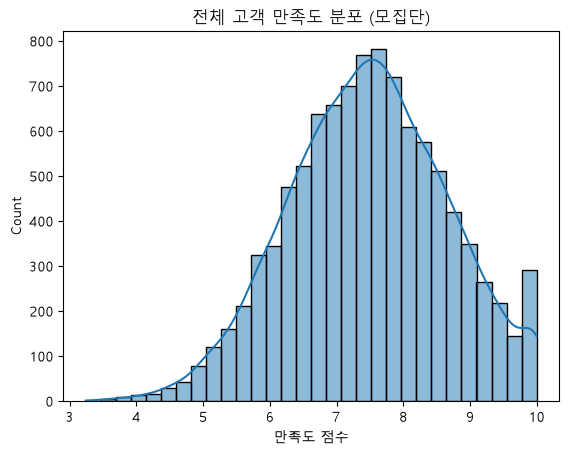

In [5]:
# 모집단 생성 (전체 고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.5, scale=1.2, size=10000)
population = np.clip(population, 1, 10)  # 1점 ~ 10점 사이로 제한
df_pop = pd.DataFrame({'score': population})

# 전체 모집단 시각화
sns.histplot(df_pop['score'], bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 표본을 무작위로 여러 번 뽑아 보고, 표본 평균이 어떻게 변하는지 확인해봅시다.

- 히스토그램을 그리고, 표본 평균의 분포 형태를 관찰해봅시다.

In [9]:
# [문제 1] Q1. 모집단에서 무작위로 30명을 뽑아 표본 평균을 구해봅시다.
# 여기에 코드를 작성해주세요.

# 재현 가능하도록 random_state 지정
sample_30 = df_pop.sample(n=30, random_state=42)

print(sample_30)
print(f"\n표본 평균: {sample_30['score'].mean():.3f}")
print(f"모집단 평균: {df_pop['score'].mean():.3f}")

          score
6252   8.356618
4684   5.434794
1731   7.588127
4742   7.309671
4521   8.303339
6340   9.041227
576    5.006368
5202   7.148221
6363   6.491795
439    8.189324
2750   5.227140
7487   7.948615
5272   7.584651
5653   7.963658
3999   6.400896
6033   7.271788
582    7.924297
9930   8.724486
7051   5.741950
8158   8.247374
9896   7.984817
2249   8.135108
4640   9.373435
9485   7.112528
4947   7.330315
9920   7.362475
1963  10.000000
8243   6.947667
6590   8.435380
8847   6.862445

표본 평균: 7.515
모집단 평균: 7.481


In [ ]:
# [문제 1] Q2. 이 과정을 500번 반복하고, 표본 평균을 리스트에 저장합니다.
# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 1] Q3. 표본 평균들의 분포를 히스토그램으로 그려봅시다. 평균선도 함께 표시해 봅시다.
# 여기에 코드를 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- 표본 평균들은 어떤 값 주변에 많이 분포해 있나요? 이 값은 전체 모집단 평균과 얼마나 비슷한가요?

- 표본을 1번 뽑았을 때와 500번을 반복해서 뽑았을 때, 표본 평균의 분포나 신뢰성에는 어떤 차이가 있나요

- 친구가 다른 표본을 뽑았다면 같은 평균이 나왔을까요? 비슷한 결과가 나왔더라도 완전히 같지 않았다면, 그 이유는 무엇일까요?

- 표본 평균들의 분포는 어떤 모양인가요? 종 모양의 정규분포처럼 보이나요? 그렇다면 왜 그렇게 되는 걸까요?

In [ ]:
# [문제 1] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

# 문제 2. 중심극한정리

**📘 문제**

- 현실에서는 모집단의 분포가 정규분포가 아닐 수도 있습니다.

- 예를 들어, 일부 고객은 매우 높은 점수를 주고, 대부분은 낮은 점수를 주는 만족도 분포가 있을 수 있죠. (예: 지수분포)

- 이처럼 원래 분포가 비정규분포여도,
  표본을 여러 번 뽑아 평균을 계산하면, 그 평균들의 분포는 정규분포에 가까워진다는 것을
  **중심극한정리(Central Limit Theorem)**라고 합니다.

- 이번 실습에서는 다양한 크기의 표본을 뽑아 평균을 계산하고,
  그 평균들의 분포가 어떻게 변하는지를 직접 실험해 봅니다.

In [ ]:
# 지수분포를 따르는 모집단 생성
np.random.seed(2025)
population = np.random.exponential(scale=50, size=100000)  # 평균 50, 비대칭 분포

# 모집단 시각화
sns.histplot(population, bins=50, kde=True)
plt.title("고객 구매 금액 분포 (모집단: 지수분포)")
plt.xlabel("구매 금액")
plt.show()

**📌 아래를 수행해 보세요:**

- 비대칭적인 모집단(지수분포)에서 무작위로 표본을 추출해 평균을 구해봅시다.

- 표본 크기를 바꿔가며, 표본 평균들의 분포가 어떻게 변화하는지 확인해봅시다.

- 히스토그램을 그리고, 분포의 모양을 관찰해봅시다.

- 표본 크기가 커질수록 표본 평균 분포의 모양과 **퍼진 정도(분산)**가 어떻게 변하는지 관찰해봅시다.

In [ ]:
# [문제 2] Q1. 모집단에서 표본을 1000번 뽑고, 각 표본의 평균을 구해봅시다.
# 표본 크기 = 5일 때

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 2] Q2. 위 과정을 표본 크기 30, 100일 때도 반복해봅시다.
# sample_size = 30, 100

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 2] Q3. 각 표본 크기별로 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 평균선을 함께 표시해 봅시다.

# 여기에 코드를 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을 때 (예: 5), 평균들의 분포는 어떤 모양인가요?

- 표본 크기가 커질수록 평균 분포의 모양은 어떤 변화를 보이나요?

- 원래 모집단은 비대칭이었는데, 왜 평균들의 분포는 정규분포처럼 바뀌었을까요?

- 이 실험을 통해 중심극한정리를 어떻게 이해하게 되었나요?

- 표본 크기에 따라 **분포의 넓이(흩어짐)**는 어떻게 달라지나요?

In [ ]:
# [문제 2]데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

# 문제 3. 표준오차

**📘 문제**

- 앞선 실습에서 우리는 **표본 크기(n)가 커질수록 표본 평균들의 분포가 더 좁아진다**는 것을 확인했습니다.
- 이처럼 표본 평균들이 얼마나 흩어져 있는지(분포의 퍼진 정도)를 나타내는 값을 **표준오차(Standard Error, SE)**라고 부릅니다.
- 표준오차는 **표본 평균들의 표준편차**와 같은 의미이며, 이는 우리가 뽑은 표본 평균이 실제 모평균과 평균적으로 얼마나 떨어져 있을지를 나타내는 **'예상 오차의 크기'**입니다.

- 통계학적으로 이 표준오차는 **`SE = σ / √n`** (모집단 표준편차 / 표본 크기의 제곱근) 이라는 공식으로 계산할 수 있습니다.
- 이 공식은 **표본 크기(n)가 커질수록 표준오차(SE)가 작아진다**는 것을 명확히 보여줍니다.

- 이번 실습에서는 여러 크기의 표본을 뽑아, 시뮬레이션을 통해 얻은 **표본 평균들의 표준편차(실험값)**가 공식으로 계산한 **표준오차(이론값)**와 얼마나 일치하는지 직접 확인해봅니다.

In [ ]:
# 모집단 생성 (평균 100, 표준편차 15)
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 100, 표준편차 15)")
plt.xlabel("값")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 여러 크기의 표본(10, 30, 100, 500)을 각각 1000번 뽑고, 그 평균들을 구한 뒤, **표본 평균들의 표준편차(=실험적 표준오차)**를 계산해봅시다.

- 이 결과를 이론적인 표준오차 공식과 비교하는 표를 만들고, 시각화해봅시다.

In [ ]:
# [문제 3] Q1. 표본 크기 10, 30, 100, 500에 대해 각각 1000번 표본을 뽑고, 평균을 구해봅시다.
# 각 표본 평균 분포의 표준편차를 계산해봅시다.
# 결과를 리스트에 저장하고, 표로 정리해봅시다.

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 3] Q2. 이론적인 표준오차와 비교해봅시다.
# [공식] 표준오차(SE) = 모집단 표준편차 / √표본크기

# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 3] Q3. 실험값과 이론값을 시각화해봅시다.
# 표본 크기를 x축, 표준오차를 y축으로 한 꺾은선 그래프를 그려봅시다.

# 여기에 코드를 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- 표본 크기가 작을수록, 표본 평균의 분포는 어떤 모양인가요? 넓게 퍼져 있나요?

- 표본 크기가 커질수록, 평균 분포는 어떻게 변하나요?

- 실험값과 이론값(공식 계산값)은 얼마나 비슷한가요?

- 왜 표본 크기가 커질수록 표준오차는 작아질까요?

In [ ]:
# [문제 3] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

# 문제 4. 신뢰구간 계산과 해석

**📘 문제**

- 표본 평균은 모집단 평균을 추정하는 좋은 점 추정(Point Estimation) 값이지만, 표본오차 때문에 정확히 일치하지는 않습니다.

- 그래서 우리는 "모집단 평균이 아마 이 범위 안에 있을 것이다"라고 **구간으로 추정(Interval Estimation)**하는 것이 더 합리적입니다. 이때 사용하는 개념이 바로 **신뢰구간(Confidence Interval)**입니다.

- 신뢰구간은 표본평균 ± 오차범위 형태로 계산되며, 이 오차범위는 신뢰수준(예: 95%, 99%)과 표본오차에 의해 결정됩니다.

- 이번 실습에서는 **모집단 표준편차(σ)를 알 때(z-분포)**와 **모를 때(t-분포)**의 신뢰구간을 각각 계산해보고, 신뢰수준에 따라 구간의 폭이 어떻게 변하는지 확인해봅니다.

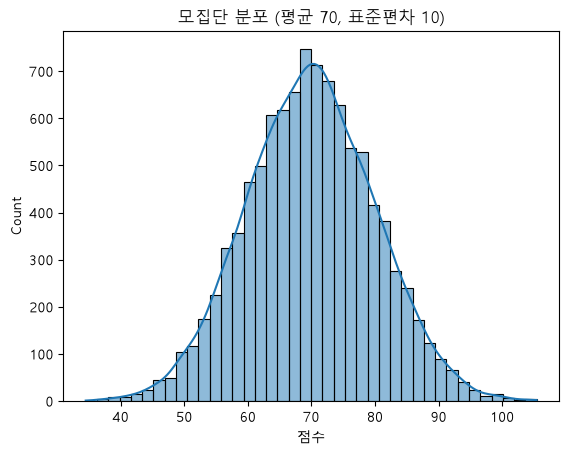

In [10]:
# 모집단 생성
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 70, 표준편차 10)")
plt.xlabel("점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단에서 30명을 무작위로 뽑아 평균, 표준편차, 표준오차를 계산해보세요.

- 95% 신뢰구간을 z-분포와 t-분포를 각각 사용해서 계산해보세요.

- 신뢰수준을 바꿨을 때(90%, 99%) 신뢰구간이 어떻게 변하는지 확인해보세요.

In [16]:
# [문제 4] Q1. 모집단에서 표본 30명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
# 표준오차도 함께 계산해보세요.

# 여기에 코드를 작성해주세요.

# 무작위로 30명 표본 추출
np.random.seed(42)
sample = np.random.choice(population, size=30, replace=False)

# 표본평균, 표본표준편차, 표준오차 계산
sample_mean = np.mean(sample) # 표본평균 계산
sample_std = np.std(sample, ddof=1)   # 표본표준편차 s 구하기, ddof=1 → n-1로 나눈 표본표준편차 (표본표준편차가 모표준편차의 비편향 추정량이 되도록 하기 위한 보정)
n = len(sample)
se = sample_std / np.sqrt(n) # 표준오차 계산

print(f"표본평균: {sample_mean:.2f}")
print(f"표본표준편차: {sample_std:.2f}")
print(f"표준오차: {se:.2f}")

표본평균: 70.28
표본표준편차: 10.19
표준오차: 1.86


모표준편차(sigma): 10.01
표본평균(x̄): 70.28
표준오차(SE = sigma/√n): 1.83
Z 임계값: 1.96
오차범위: 3.58

95% 신뢰구간 (Z-분포): [66.70, 73.86]


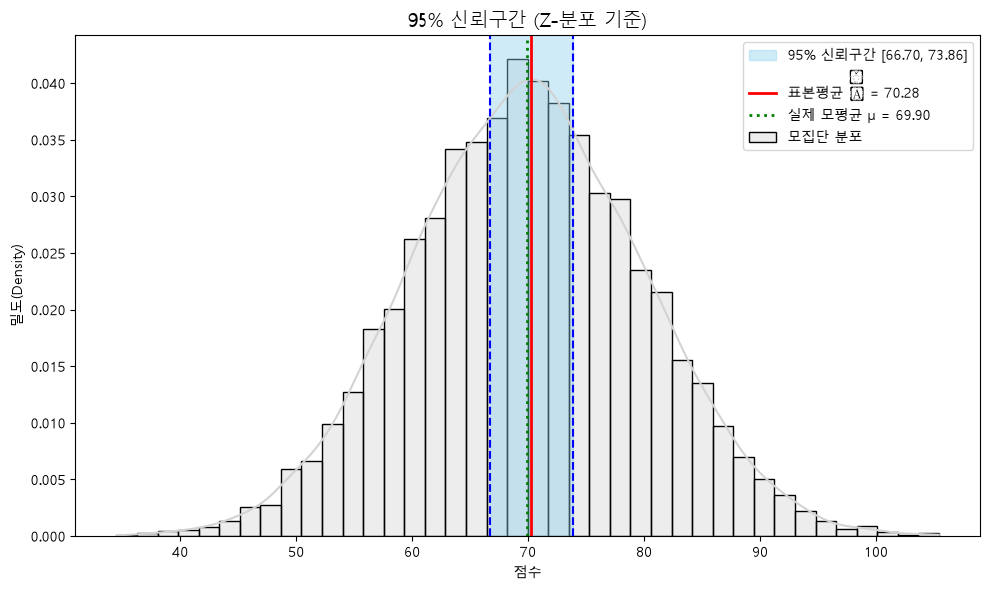

In [18]:
# [문제 4] Q2. 모집단의 표준편차를 알고 있다고 가정하고, z-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

# 여기에 코드를 작성해주세요.

# ============================================
# Z-분포 신뢰구간 계산에 필요한 값들
# ============================================
n = len(sample)                # 표본 크기 = 30
sample_mean = np.mean(sample)  # 표본평균 (mu의 추정치)

# 핵심 가정: 모표준편차(sigma)를 "알고 있다"고 가정
# 실무에서는 거의 불가능한 가정이지만, Z-분포를 쓰려면 이 가정이 필요함
sigma = population.std(ddof=0)  # ddof=0: 모집단 전체이므로 n으로 나눈 표준편차

# 모표준편차(sigma)를 안다는 가정이므로,
# 표준오차(SE)는 "표본표준편차(s)"가 아니라 "모표준편차(sigma)"로 계산
# → 이 부분이 t-분포와 결정적으로 다른 지점!
se = sigma / np.sqrt(n)

# ============================================
# Z 임계값(critical value) 구하기
# ============================================
# 95% 신뢰구간 → 양쪽 꼬리에 각각 2.5%씩 남기고 싶음
# 평균 ± 1.96×표준편차 = 약 95% (근사치)
z_critical = 1.96

# ============================================
# 신뢰구간 계산
# ============================================
# 공식: 표본평균 ± (z임계값 × 표준오차)
margin_of_error = z_critical * se
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

# ============================================
# 6. 결과 출력
# ============================================
print(f"모표준편차(sigma): {sigma:.2f}")
print(f"표본평균(x̄): {sample_mean:.2f}")
print(f"표준오차(SE = sigma/√n): {se:.2f}")
print(f"Z 임계값: {z_critical:.2f}")
print(f"오차범위: {margin_of_error:.2f}")
print(f"\n95% 신뢰구간 (Z-분포): [{ci_lower:.2f}, {ci_upper:.2f}]")

# ============================================
# 그래프 그리기
# ============================================
pop_mean = population.mean()

fig, ax = plt.subplots(figsize=(10, 6))

# 1) 모집단 분포를 배경으로 표시 (히스토그램, 연하게)
sns.histplot(population, bins=40, kde=True, stat='density',
             color='lightgray', alpha=0.4, ax=ax, label='모집단 분포')

# 2) 신뢰구간을 색칠된 구간으로 표시
ax.axvspan(ci_lower, ci_upper, color='skyblue', alpha=0.4,
           label=f'95% 신뢰구간 [{ci_lower:.2f}, {ci_upper:.2f}]')

# 3) 신뢰구간 경계선 (점선)
ax.axvline(ci_lower, color='blue', linestyle='--', linewidth=1.5)
ax.axvline(ci_upper, color='blue', linestyle='--', linewidth=1.5)

# 4) 표본평균 위치 (빨간 실선)
ax.axvline(sample_mean, color='red', linestyle='-', linewidth=2,
           label=f'표본평균 x̄ = {sample_mean:.2f}')

# 5) 실제 모평균 위치 (초록 점선) → 신뢰구간이 실제로 맞혔는지 눈으로 확인
ax.axvline(pop_mean, color='green', linestyle=':', linewidth=2,
           label=f'실제 모평균 μ = {pop_mean:.2f}')

ax.set_title('95% 신뢰구간 (Z-분포 기준)', fontsize=14)
ax.set_xlabel('점수')
ax.set_ylabel('밀도(Density)')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

표본표준편차(s): 10.19
표본평균(x̄): 70.28
표준오차(SE = s/√n): 1.86
자유도(df = n-1): 29
t 임계값: 2.05
오차범위: 3.80

95% 신뢰구간 (t-분포): [66.48, 74.09]


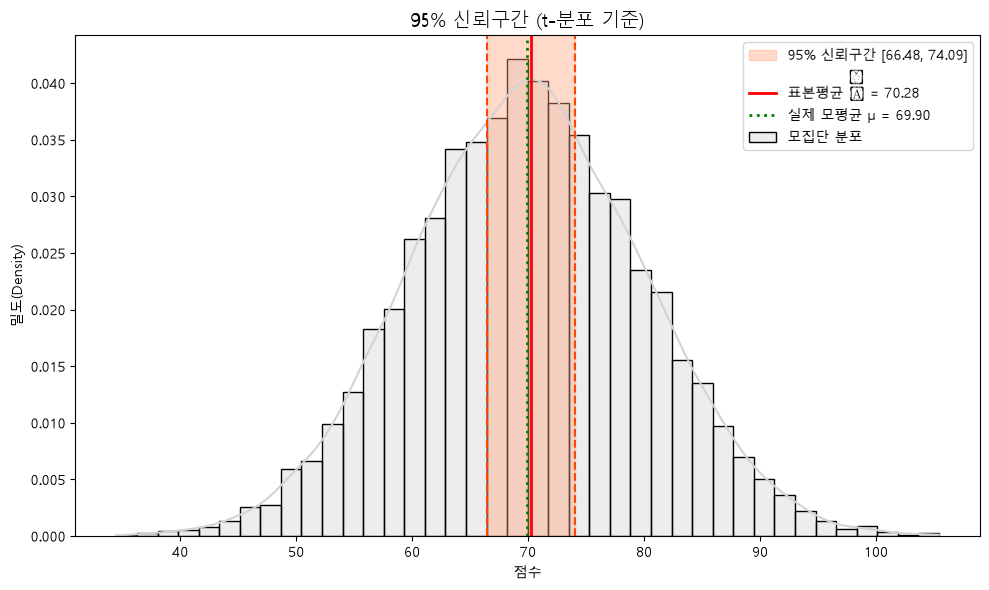

In [19]:
# [문제 4] Q3. 모집단의 표준편차를 모른다고 가정하고, 표본 표준편차와 t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

# 여기에 코드를 작성해주세요.
# ============================================
# t-분포 신뢰구간 계산에 필요한 값들
# ============================================
n = len(sample)                # 표본 크기 = 30
sample_mean = np.mean(sample)  # 표본평균 (mu의 추정치)

# 핵심 가정: 모표준편차(sigma)를 "모른다"고 가정
# 실무에서 가장 흔한 상황 → 표본에서 추정한 s로 sigma를 대신함
s = np.std(sample, ddof=1)  # ddof=1: 표본이므로 n-1로 나눈 표본표준편차 (비편향 추정량)

# 모표준편차(sigma)를 모른다는 가정이므로,
# 표준오차(SE)는 "모표준편차(sigma)"가 아니라 "표본표준편차(s)"로 계산
# → 이 부분이 Z-분포와 결정적으로 다른 지점!
se = s / np.sqrt(n)

# ============================================
# t 임계값(critical value) 구하기
# ============================================
# 95% 신뢰구간 → 양쪽 꼬리에 각각 2.5%씩 남기고 싶음
# t-분포는 표본 크기(n)에 따라 모양이 달라지므로, 자유도(df=n-1)를 반드시 지정해야 함
# Z-분포처럼 고정된 1.96이 아니라, df에 따라 값이 달라짐 (df가 작을수록 꼬리가 두꺼워 임계값이 더 큼)
df = n - 1  # 자유도 = 표본크기 - 1 = 29
t_critical = stats.t.ppf(0.975, df=df)

# ============================================
# 신뢰구간 계산
# ============================================
# 공식: 표본평균 ± (t임계값 × 표준오차)
margin_of_error = t_critical * se
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

# ============================================
# 결과 출력
# ============================================
print(f"표본표준편차(s): {s:.2f}")
print(f"표본평균(x̄): {sample_mean:.2f}")
print(f"표준오차(SE = s/√n): {se:.2f}")
print(f"자유도(df = n-1): {df}")
print(f"t 임계값: {t_critical:.2f}")
print(f"오차범위: {margin_of_error:.2f}")
print(f"\n95% 신뢰구간 (t-분포): [{ci_lower:.2f}, {ci_upper:.2f}]")

# ============================================
# 그래프 그리기
# ============================================
pop_mean = population.mean()

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(population, bins=40, kde=True, stat='density',
             color='lightgray', alpha=0.4, ax=ax, label='모집단 분포')

ax.axvspan(ci_lower, ci_upper, color='lightsalmon', alpha=0.4,
           label=f'95% 신뢰구간 [{ci_lower:.2f}, {ci_upper:.2f}]')

ax.axvline(ci_lower, color='orangered', linestyle='--', linewidth=1.5)
ax.axvline(ci_upper, color='orangered', linestyle='--', linewidth=1.5)

ax.axvline(sample_mean, color='red', linestyle='-', linewidth=2,
           label=f'표본평균 x̄ = {sample_mean:.2f}')

ax.axvline(pop_mean, color='green', linestyle=':', linewidth=2,
           label=f'실제 모평균 μ = {pop_mean:.2f}')

ax.set_title('95% 신뢰구간 (t-분포 기준)', fontsize=14)
ax.set_xlabel('점수')
ax.set_ylabel('밀도(Density)')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()


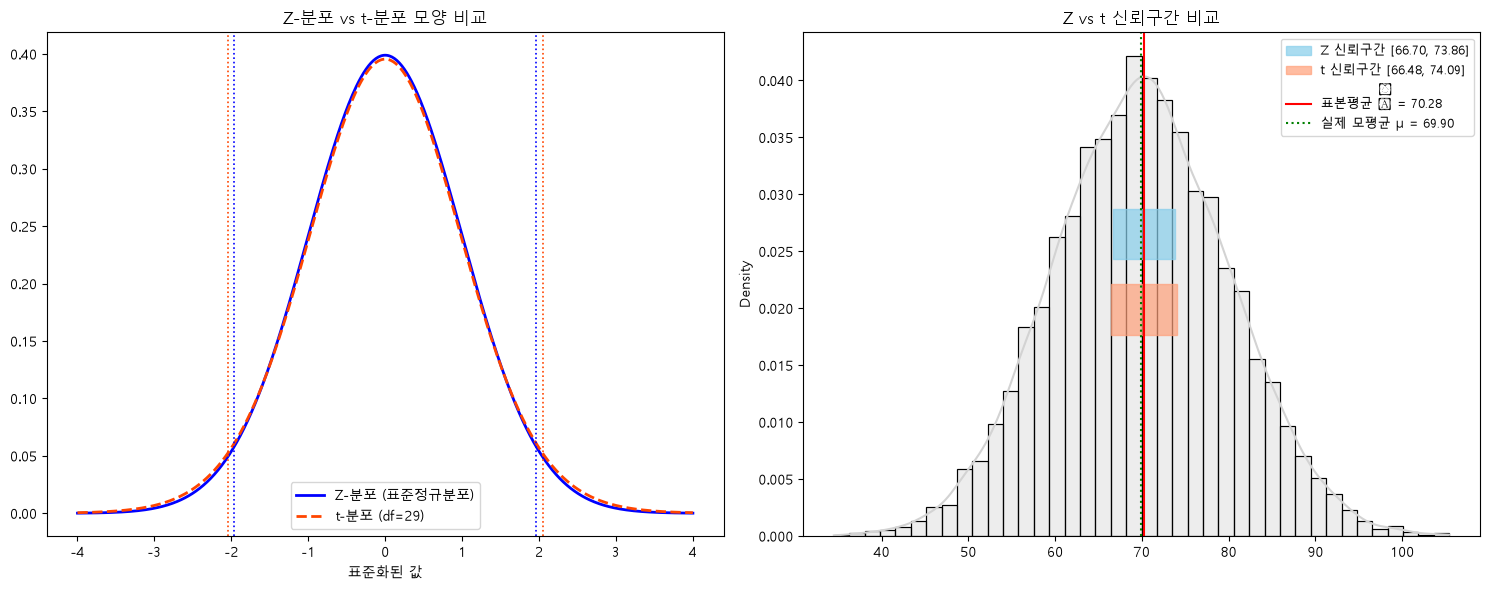

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 모집단 및 표본
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)
np.random.seed(42)
sample = np.random.choice(population, size=30, replace=False)

n = len(sample)
sample_mean = np.mean(sample)
pop_mean = population.mean()

# Z-분포 신뢰구간
sigma = population.std(ddof=0)
se_z = sigma / np.sqrt(n)
z_critical = 1.96
moe_z = z_critical * se_z
ci_lower_z, ci_upper_z = sample_mean - moe_z, sample_mean + moe_z

# t-분포 신뢰구간
s = np.std(sample, ddof=1)
se_t = s / np.sqrt(n)
df = n - 1
t_critical = stats.t.ppf(0.975, df=df)
moe_t = t_critical * se_t
ci_lower_t, ci_upper_t = sample_mean - moe_t, sample_mean + moe_t

# ============================================
# 그래프 그리기 (왼쪽: 분포 모양 비교 / 오른쪽: 신뢰구간 비교)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 왼쪽: Z-분포 vs t-분포 모양 비교
ax1 = axes[0]
x = np.linspace(-4, 4, 500)
ax1.plot(x, stats.norm.pdf(x), color='blue', linewidth=2, label='Z-분포 (표준정규분포)')
ax1.plot(x, stats.t.pdf(x, df=df), color='orangered', linewidth=2, linestyle='--', label=f't-분포 (df={df})')
ax1.axvline(z_critical, color='blue', linestyle=':', linewidth=1.2)
ax1.axvline(-z_critical, color='blue', linestyle=':', linewidth=1.2)
ax1.axvline(t_critical, color='orangered', linestyle=':', linewidth=1.2)
ax1.axvline(-t_critical, color='orangered', linestyle=':', linewidth=1.2)
ax1.set_title('Z-분포 vs t-분포 모양 비교')
ax1.set_xlabel('표준화된 값')
ax1.legend()

# 오른쪽: 신뢰구간 비교 (모집단 위에 표시)
ax2 = axes[1]
sns.histplot(population, bins=40, kde=True, stat='density', color='lightgray', alpha=0.4, ax=ax2)
ax2.axvspan(ci_lower_z, ci_upper_z, ymin=0.55, ymax=0.65, color='skyblue', alpha=0.7,
            label=f'Z 신뢰구간 [{ci_lower_z:.2f}, {ci_upper_z:.2f}]')
ax2.axvspan(ci_lower_t, ci_upper_t, ymin=0.40, ymax=0.50, color='lightsalmon', alpha=0.7,
            label=f't 신뢰구간 [{ci_lower_t:.2f}, {ci_upper_t:.2f}]')
ax2.axvline(sample_mean, color='red', label=f'표본평균 x̄ = {sample_mean:.2f}')
ax2.axvline(pop_mean, color='green', linestyle=':', label=f'실제 모평균 μ = {pop_mean:.2f}')
ax2.set_title('Z vs t 신뢰구간 비교')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

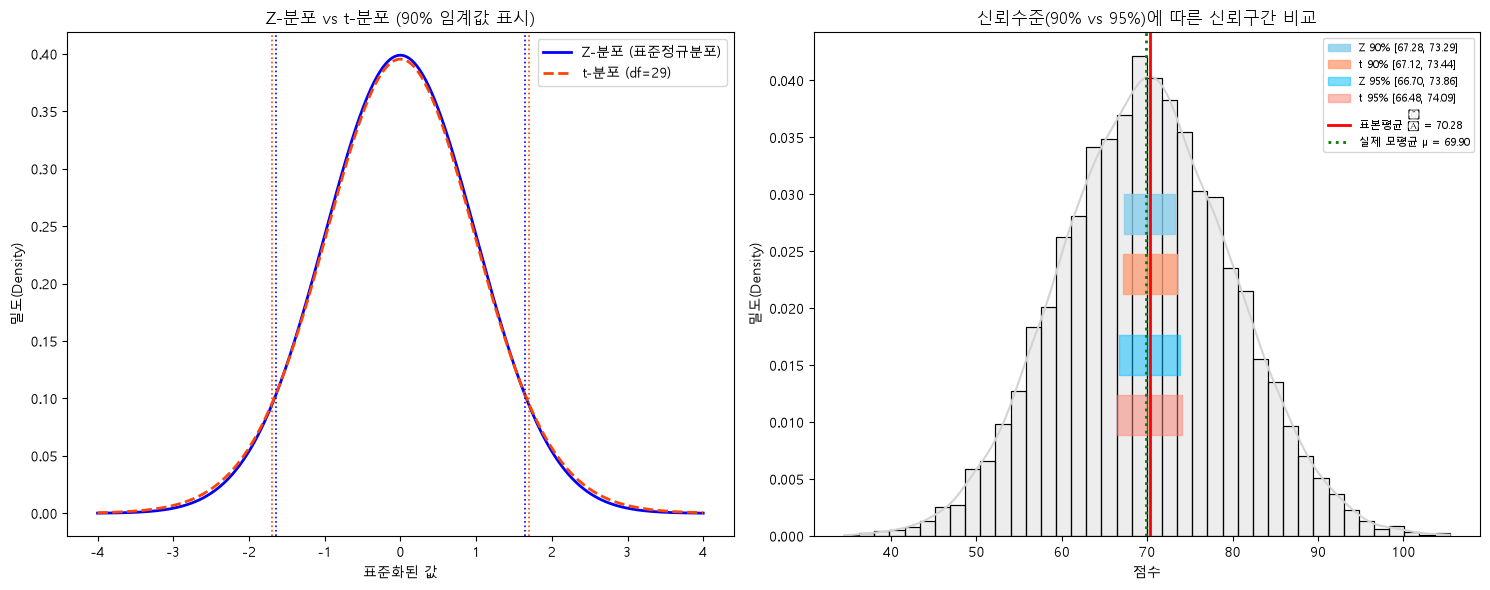

In [30]:
# [문제 4] Q4. 신뢰수준을 90%, 99%로 바꿔가며 신뢰구간을 계산해보고, 그 폭을 비교해봅시다.

# 여기에 코드를 작성해주세요.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 모집단 및 표본
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)
np.random.seed(42)
sample = np.random.choice(population, size=30, replace=False)

n = len(sample)
sample_mean = np.mean(sample)
pop_mean = population.mean()
df = n - 1

# ============================================
# 90% 신뢰구간 계산
# ============================================
sigma = population.std(ddof=0)
se_z = sigma / np.sqrt(n)
z_critical_90 = stats.norm.ppf(0.95)
moe_z_90 = z_critical_90 * se_z
ci_lower_z90, ci_upper_z90 = sample_mean - moe_z_90, sample_mean + moe_z_90

s = np.std(sample, ddof=1)
se_t = s / np.sqrt(n)
t_critical_90 = stats.t.ppf(0.95, df=df)
moe_t_90 = t_critical_90 * se_t
ci_lower_t90, ci_upper_t90 = sample_mean - moe_t_90, sample_mean + moe_t_90

# ============================================
# 95% 신뢰구간 계산 (비교용)
# ============================================
z_critical_95 = 1.96
moe_z_95 = z_critical_95 * se_z
ci_lower_z95, ci_upper_z95 = sample_mean - moe_z_95, sample_mean + moe_z_95

t_critical_95 = stats.t.ppf(0.975, df=df)
moe_t_95 = t_critical_95 * se_t
ci_lower_t95, ci_upper_t95 = sample_mean - moe_t_95, sample_mean + moe_t_95

# ============================================
# 그래프 그리기 (왼쪽: 분포 모양 / 오른쪽: 90% vs 95% 신뢰구간 비교)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 왼쪽: Z-분포 vs t-분포 모양, 90% 임계값 표시
ax1 = axes[0]
x = np.linspace(-4, 4, 500)
ax1.plot(x, stats.norm.pdf(x), color='blue', linewidth=2, label='Z-분포 (표준정규분포)')
ax1.plot(x, stats.t.pdf(x, df=df), color='orangered', linewidth=2, linestyle='--', label=f't-분포 (df={df})')
ax1.axvline(z_critical_90, color='blue', linestyle=':', linewidth=1.2)
ax1.axvline(-z_critical_90, color='blue', linestyle=':', linewidth=1.2)
ax1.axvline(t_critical_90, color='orangered', linestyle=':', linewidth=1.2)
ax1.axvline(-t_critical_90, color='orangered', linestyle=':', linewidth=1.2)
ax1.set_title('Z-분포 vs t-분포 (90% 임계값 표시)')
ax1.set_xlabel('표준화된 값')
ax1.set_ylabel('밀도(Density)')
ax1.legend(fontsize=10)

# 오른쪽: 신뢰수준별(90% vs 95%) 신뢰구간 비교
ax2 = axes[1]
sns.histplot(population, bins=40, kde=True, stat='density',
             color='lightgray', alpha=0.4, ax=ax2)

# 90% 구간 (좁음, 진한 색)
ax2.axvspan(ci_lower_z90, ci_upper_z90, ymin=0.60, ymax=0.68, color='skyblue', alpha=0.8,
            label=f'Z 90% [{ci_lower_z90:.2f}, {ci_upper_z90:.2f}]')
ax2.axvspan(ci_lower_t90, ci_upper_t90, ymin=0.48, ymax=0.56, color='lightsalmon', alpha=0.8,
            label=f't 90% [{ci_lower_t90:.2f}, {ci_upper_t90:.2f}]')

# 95% 구간 (넓음, 연한 색)
ax2.axvspan(ci_lower_z95, ci_upper_z95, ymin=0.32, ymax=0.40, color='deepskyblue', alpha=0.5,
            label=f'Z 95% [{ci_lower_z95:.2f}, {ci_upper_z95:.2f}]')
ax2.axvspan(ci_lower_t95, ci_upper_t95, ymin=0.20, ymax=0.28, color='salmon', alpha=0.5,
            label=f't 95% [{ci_lower_t95:.2f}, {ci_upper_t95:.2f}]')

ax2.axvline(sample_mean, color='red', linestyle='-', linewidth=2, label=f'표본평균 x̄ = {sample_mean:.2f}')
ax2.axvline(pop_mean, color='green', linestyle=':', linewidth=2, label=f'실제 모평균 μ = {pop_mean:.2f}')

ax2.set_title('신뢰수준(90% vs 95%)에 따른 신뢰구간 비교')
ax2.set_xlabel('점수')
ax2.set_ylabel('밀도(Density)')
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()



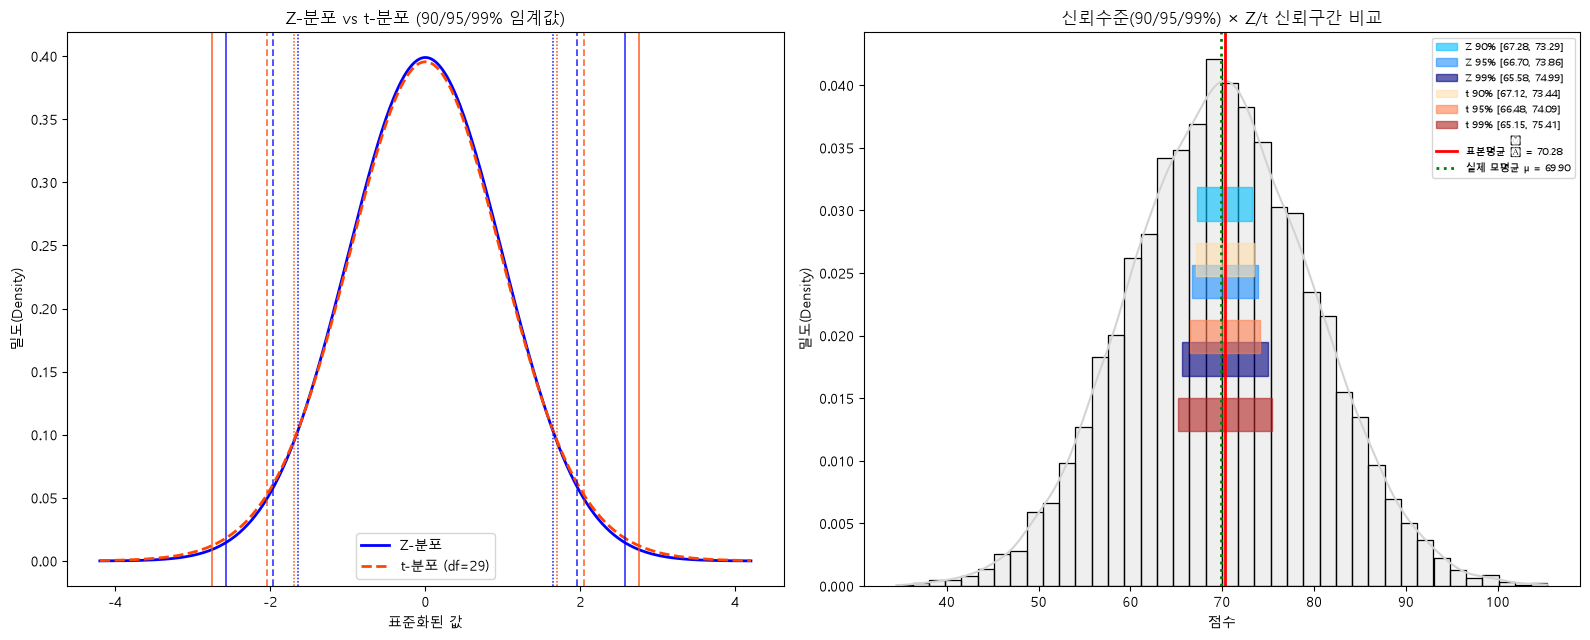

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 모집단 및 표본
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)
np.random.seed(42)
sample = np.random.choice(population, size=30, replace=False)

n = len(sample)
sample_mean = np.mean(sample)
pop_mean = population.mean()
df = n - 1

sigma = population.std(ddof=0)
se_z = sigma / np.sqrt(n)
s = np.std(sample, ddof=1)
se_t = s / np.sqrt(n)

# ============================================
# 신뢰수준별(90%, 95%, 99%) Z/t 신뢰구간 계산
# ============================================
confidence_levels = [0.90, 0.95, 0.99]
results = {}

for cl in confidence_levels:
    alpha = 1 - cl
    upper_tail = 1 - alpha/2  # 양쪽 꼬리 각각 alpha/2씩 남기는 누적확률 지점

    z_crit = stats.norm.ppf(upper_tail)
    t_crit = stats.t.ppf(upper_tail, df=df)

    moe_z = z_crit * se_z
    moe_t = t_crit * se_t

    results[cl] = {
        'z_crit': z_crit, 't_crit': t_crit,
        'z_ci': (sample_mean - moe_z, sample_mean + moe_z),
        't_ci': (sample_mean - moe_t, sample_mean + moe_t),
    }

# ============================================
# 그래프 그리기 (왼쪽: 분포+임계값 / 오른쪽: 신뢰구간 비교)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# 왼쪽: Z-분포 vs t-분포, 90/95/99% 임계값 표시
ax1 = axes[0]
x = np.linspace(-4.2, 4.2, 500)
ax1.plot(x, stats.norm.pdf(x), color='blue', linewidth=2, label='Z-분포')
ax1.plot(x, stats.t.pdf(x, df=df), color='orangered', linewidth=2, linestyle='--', label=f't-분포 (df={df})')

line_styles = {0.90: (0, (1,1)), 0.95: (0, (4,2)), 0.99: 'solid'}
for cl in confidence_levels:
    z_c, t_c = results[cl]['z_crit'], results[cl]['t_crit']
    ls = line_styles[cl]
    ax1.axvline(z_c, color='blue', linestyle=ls, linewidth=1.2, alpha=0.8)
    ax1.axvline(-z_c, color='blue', linestyle=ls, linewidth=1.2, alpha=0.8)
    ax1.axvline(t_c, color='orangered', linestyle=ls, linewidth=1.2, alpha=0.8)
    ax1.axvline(-t_c, color='orangered', linestyle=ls, linewidth=1.2, alpha=0.8)

ax1.set_title('Z-분포 vs t-분포 (90/95/99% 임계값)')
ax1.set_xlabel('표준화된 값')
ax1.set_ylabel('밀도(Density)')
ax1.legend(fontsize=10)

# 오른쪽: 신뢰수준별 신뢰구간 비교 (모집단 배경)
ax2 = axes[1]
sns.histplot(population, bins=40, kde=True, stat='density',
             color='lightgray', alpha=0.35, ax=ax2)

y_positions = {0.90: (0.66, 0.72), 0.95: (0.52, 0.58), 0.99: (0.38, 0.44)}
blue_shades = {0.90: 'deepskyblue', 0.95: 'dodgerblue', 0.99: 'navy'}
orange_shades = {0.90: 'navajowhite', 0.95: 'coral', 0.99: 'firebrick'}

for cl in confidence_levels:
    ylo, yhi = y_positions[cl]
    z_lo, z_hi = results[cl]['z_ci']
    ax2.axvspan(z_lo, z_hi, ymin=ylo, ymax=yhi, color=blue_shades[cl], alpha=0.6,
                label=f'Z {int(cl*100)}% [{z_lo:.2f}, {z_hi:.2f}]')

for cl in confidence_levels:
    ylo, yhi = (y_positions[cl][0]-0.10, y_positions[cl][1]-0.10)
    t_lo, t_hi = results[cl]['t_ci']
    ax2.axvspan(t_lo, t_hi, ymin=ylo, ymax=yhi, color=orange_shades[cl], alpha=0.6,
                label=f't {int(cl*100)}% [{t_lo:.2f}, {t_hi:.2f}]')

ax2.axvline(sample_mean, color='red', linewidth=2, label=f'표본평균 x̄ = {sample_mean:.2f}')
ax2.axvline(pop_mean, color='green', linestyle=':', linewidth=2, label=f'실제 모평균 μ = {pop_mean:.2f}')

ax2.set_title('신뢰수준(90/95/99%) × Z/t 신뢰구간 비교')
ax2.set_xlabel('점수')
ax2.set_ylabel('밀도(Density)')
ax2.legend(fontsize=7.5, loc='upper right')

plt.tight_layout()
plt.show()

모표준편차(σ)를 정말로 알고 있다면, Z-분포를 쓰는 게 이론적으로 정확한 방법입니다.

왜 그런가

t-분포는 애초에 "σ를 모른다"는 상황을 위해 만들어진 도구입니다. σ 대신 s(표본표준편차)를 쓰면서 생기는 추가적인 불확실성을 보정하려고 꼬리를 일부러 두껍게 만든 거죠.

그런데 만약 σ를 이미 알고 있다면, 애초에 t-분포가 보정하려던 그 "불확실성"이 존재하지 않습니다. 이 상황에서 t-분포를 쓰면 존재하지도 않는 불확실성까지 반영해서 신뢰구간을 필요 이상으로 넓게 잡는 셈이 됩니다. 즉 t를 쓰면 오히려 과도하게 보수적인(넓은) 결과가 나와서, 정확도가 떨어지는 게 아니라 불필요하게 넓은 구간을 만들게 됩니다.

정리
상황	맞는 분포	틀린 분포를 쓰면
σ를 안다	Z-분포 (정확)	t를 쓰면 → 불필요하게 넓은 구간 (과잉 보수적)
σ를 모른다	t-분포 (정확)	Z를 쓰면 → 너무 좁은 구간 (과신, 위험)
그런데 현실적으로

"σ를 안다"는 가정 자체가 실무에서는 거의 성립하지 않습니다. 지금까지 실습에서 σ=10을 쓸 수 있었던 이유는 우리가 population을 직접 만들어서 "신(神)의 시점"으로 답을 미리 알고 있었기 때문입니다.

현실에서 σ를 안다고 할 수 있는 몇 가지 드문 경우:

대규모 표준화 시험(예: 전국 단위 시험)처럼, 과거 데이터로 σ가 이미 안정적으로 확립되어 있고 공식적으로 공표된 경우
제조 공정처럼 기계의 오차 범위(σ)가 스펙으로 정해져 있는 경우

대부분의 실무 데이터 분석(설문조사, A/B테스트, 표본 실험 등)에서는 σ를 모르는 게 기본값이라서, 실제로는 t-분포를 쓰는 게 표준 관행입니다. "Z를 쓸 수 있는 상황"을 만나는 경우 자체가 드물다고 보시면 됩니다.

**🧠 데이터를 어떻게 읽을까요?**

- z-분포와 t-분포를 사용한 신뢰구간은 얼마나 차이가 있나요?

- 신뢰수준이 높아질수록 신뢰구간의 폭은 어떻게 변하나요? 왜 그럴까요?

- 신뢰구간이 넓다는 건 좋은 걸까요? 나쁜 걸까요?

- 이 데이터가 실제 고객 만족도라면, 신뢰구간 정보를 마케팅 전략에 어떻게 활용할 수 있을까요?

In [ ]:
# [문제 4] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.

- z-분포와 t-분포를 사용한 신뢰구간은 얼마나 차이가 있나요?
표본 크기가 커질수록, Z-분포와 t-분포의 신뢰구간 차이는 크지 않습니다. 하지만 신뢰수준이 높아질수록, 그리고 표본 크기가 작아질수록 그 차이는 벌어집니다.

- 신뢰수준이 높아질수록 신뢰구간의 폭은 어떻게 변하나요? 왜 그럴까요?
더 넓어짐. 모평균이 특정 범위안에 있다고 더 확신있게 말하기 위해서는 범위를 더 넓게 잡을수록 그 가능성이 높아짐. 그물의 넓이처럼

- 신뢰구간이 넓다는 건 좋은 걸까요? 나쁜 걸까요?
신뢰구간은 동일 신뢰수준하에서 표본 크기에 따라 달라진다, 정확도를 위해서는 표분크기가 충분히 확보된, 더 좁은 신뢰구간이 더 정확함
    - 표본이 클수록 표준오차는 작아짐 (√n이 표준오차 계산 시 분모), 신뢰구간은 (2 * 임계값 * 표준오차), 표준오차가 작아짐에 따라서 신뢰구간도 작아짐
    - 표본이 작아질수록 표준오차는 커짐, 표준오차가 커짐에 따라 신뢰구간도 커짐.
도메인에 따라 허용되는 신뢰수준하에서, 더 정확한 분석을 위해 충분한 표본이 필요하고, 신뢰구간이 넓을 경우 표본이 충분히 수집되지 않았을 경우이기 때문에 부정확함.

- 이 데이터가 실제 고객 만족도라면, 신뢰구간 정보를 마케팅 전략에 어떻게 활용할 수 있을까요?
단순 고객만족도 평균이 아닌, 특정 신뢰수준하에서 발생하는 신뢰구간 범위를 함께 언급하여 데이터의 신뢰도 확보
고객 만족도 KPI 설계 시 업계 기준 신뢰수준을 기반으로 얼마만큼의 표본이 확보되어야 하는지 미리 파악, 고객 만족도 조사 작업에 필요 예산 계획 가능  
파일럿 조사(소규모 표본)에서 나온 결과의 신뢰구간이 지나치게 넓다면, **"이 결과만으로 전국 출시를 결정하기엔 근거가 부족하다"**는 신호로 활용해서, 본조사(대규모 표본)를 진행할지 여부를 판단하는 데 씁니다.


# 문제 5. 미니 프로젝트 - 고객 만족도 신뢰구간 추정

**📘 문제**

- 전체 고객 10,000명을 대상으로 만족도 조사를 하는 것은 시간과 비용이 많이 듭니다.
- 그래서 우리는 무작위로 일부 고객만 조사하여, 전체 고객의 평균 만족도를 추정하려 합니다.

- 이 프로젝트에서는 실제와 같은 상황을 가정하여, 표본을 뽑고 신뢰구간을 계산한 뒤, 이 결과를 바탕으로 마케팅 전략에 어떻게 활용할 수 있을지까지 생각해보는 실습을 진행합니다.

In [ ]:
# 모집단 생성 (고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.2, scale=1.0, size=10000)
population = np.clip(population, 1, 10)

# 모집단 시각화
sns.histplot(population, bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

**📌 아래를 수행해 보세요:**

- 모집단을 생성하고, 거기서 표본을 40명 뽑아 평균을 계산해봅시다.

- 표본 평균과 표준편차를 바탕으로 95% 신뢰구간을 계산해봅시다.

- 히스토그램을 그리고 신뢰구간을 시각화해봅시다.

- 이 결과를 어떻게 해석하고, 마케팅 전략에 활용할 수 있을지 생각해봅시다.

In [ ]:
# [문제 5] Q1. 모집단에서 표본 40명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q2. 표준오차(SE)를 구하고, t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.
# 여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q3. 표본 데이터의 히스토그램을 그리고, 평균 및 신뢰구간을 함께 시각화해봅시다.
#  여기에 코드를 작성해주세요.

In [ ]:
# [문제 5] Q4. 신뢰구간의 결과에 따라 어떤 구체적인 마케팅 전략을 세울 수 있을까요?
# 여기에 의견을 작성해주세요.

**🧠 데이터를 어떻게 읽을까요?**

- 신뢰구간은 몇 점에서 몇 점 사이인가요?

- 이 구간은 전체 모집단 평균을 포함하고 있나요?

- 이 결과를 바탕으로 고객 만족도가 충분히 높다고 말할 수 있을까요?

- 만약 신뢰구간이 너무 넓게 나왔다면, 그 이유는 무엇이고 어떻게 개선할 수 있을까요?

In [ ]:
# [문제 5] 데이터를 어떻게 읽을까요?
# 여기에 의견을 작성해주세요.